In [1]:
import matplotlib.pyplot as plt

from hea import data
from hea.models import lm, lme
from hea.R import factor, anova


### 1.3

In [2]:
Dyestuff = data("Dyestuff", "lme4")
Dyestuff = Dyestuff.with_columns(factor(Dyestuff["Batch"]))
Dyestuff.describe(), Dyestuff["Batch"].value_counts()

(shape: (9, 3)
 ┌────────────┬───────┬───────────┐
 │ statistic  ┆ Batch ┆ Yield     │
 │ ---        ┆ ---   ┆ ---       │
 │ str        ┆ str   ┆ f64       │
 ╞════════════╪═══════╪═══════════╡
 │ count      ┆ 30    ┆ 30.0      │
 │ null_count ┆ 0     ┆ 0.0       │
 │ mean       ┆ null  ┆ 1527.5    │
 │ std        ┆ null  ┆ 63.023668 │
 │ min        ┆ null  ┆ 1440.0    │
 │ 25%        ┆ null  ┆ 1465.0    │
 │ 50%        ┆ null  ┆ 1540.0    │
 │ 75%        ┆ null  ┆ 1580.0    │
 │ max        ┆ null  ┆ 1635.0    │
 └────────────┴───────┴───────────┘,
 shape: (6, 2)
 ┌───────┬───────┐
 │ Batch ┆ count │
 │ ---   ┆ ---   │
 │ enum  ┆ u32   │
 ╞═══════╪═══════╡
 │ F     ┆ 5     │
 │ A     ┆ 5     │
 │ C     ┆ 5     │
 │ B     ┆ 5     │
 │ E     ┆ 5     │
 │ D     ┆ 5     │
 └───────┴───────┘)

In [3]:
Dyestuff2 = data("Dyestuff2", "lme4")
Dyestuff2 = Dyestuff2.with_columns(factor(Dyestuff2["Batch"]))
Dyestuff2.describe(), Dyestuff2["Batch"].value_counts()

(shape: (9, 3)
 ┌────────────┬───────┬──────────┐
 │ statistic  ┆ Batch ┆ Yield    │
 │ ---        ┆ ---   ┆ ---      │
 │ str        ┆ str   ┆ f64      │
 ╞════════════╪═══════╪══════════╡
 │ count      ┆ 30    ┆ 30.0     │
 │ null_count ┆ 0     ┆ 0.0      │
 │ mean       ┆ null  ┆ 5.6656   │
 │ std        ┆ null  ┆ 3.715684 │
 │ min        ┆ null  ┆ -0.892   │
 │ 25%        ┆ null  ┆ 2.434    │
 │ 50%        ┆ null  ┆ 5.51     │
 │ 75%        ┆ null  ┆ 8.166    │
 │ max        ┆ null  ┆ 13.434   │
 └────────────┴───────┴──────────┘,
 shape: (6, 2)
 ┌───────┬───────┐
 │ Batch ┆ count │
 │ ---   ┆ ---   │
 │ enum  ┆ u32   │
 ╞═══════╪═══════╡
 │ F     ┆ 5     │
 │ A     ┆ 5     │
 │ D     ┆ 5     │
 │ B     ┆ 5     │
 │ C     ┆ 5     │
 │ E     ┆ 5     │
 └───────┴───────┘)

In [4]:
fm01 = lme("Yield ~ 1 + (1 | Batch)", Dyestuff)
fm01.summary()

Linear mixed model fit by REML
Formula: Yield ~ 1 + (1 | Batch)

REML criterion at convergence: 319.6543

Scaled residuals:
    Min      1Q Median     3Q    Max
-1.4117 -0.7634 0.1418 0.7792 1.8296

Random effects:
 Groups   Name        Variance Std.Dev.
 Batch    (Intercept) 1764     42.00
 Residual             2451     49.51
Number of obs: 30, groups:  Batch, 6

Fixed effects:
             Estimate  Std. Error  t value
(Intercept)   1527.50       19.38    78.80


In [5]:
fm01ML = lme("Yield ~ 1 + (1 | Batch)", Dyestuff, REML=False)
fm01ML.summary()

Linear mixed model fit by maximum likelihood
Formula: Yield ~ 1 + (1 | Batch)

     AIC      BIC    logLik -2*log(L) df.resid
333.3271 337.5307 -163.6635  327.3271       27

Scaled residuals:
    Min      1Q Median     3Q    Max
-1.4315 -0.7972 0.1480 0.7721 1.8037

Random effects:
 Groups   Name        Variance Std.Dev.
 Batch    (Intercept) 1388     37.26
 Residual             2451     49.51
Number of obs: 30, groups:  Batch, 6

Fixed effects:
             Estimate  Std. Error  t value
(Intercept)   1527.50       17.69    86.33


In [6]:
fm02 = lme("Yield ~ 1 + (1 | Batch)", Dyestuff2)
fm02.summary()

Linear mixed model fit by REML
Formula: Yield ~ 1 + (1 | Batch)

REML criterion at convergence: 161.8283

Scaled residuals:
    Min      1Q  Median     3Q    Max
-1.7648 -0.7806 -0.0809 0.6689 2.0907

Random effects:
 Groups   Name        Variance Std.Dev.
 Batch    (Intercept) 0.00     0.000
 Residual             13.81    3.716
Number of obs: 30, groups:  Batch, 6

Fixed effects:
             Estimate  Std. Error  t value
(Intercept)    5.6656      0.6784    8.352


In [7]:
fm02ML = lme("Yield ~ 1 + (1 | Batch)", Dyestuff2, REML=False)
fm02ML.summary()

Linear mixed model fit by maximum likelihood
Formula: Yield ~ 1 + (1 | Batch)

     AIC      BIC   logLik -2*log(L) df.resid
168.8730 173.0766 -81.4365  162.8730       27

Scaled residuals:
    Min      1Q  Median     3Q    Max
-1.7950 -0.7940 -0.0823 0.6803 2.1264

Random effects:
 Groups   Name        Variance Std.Dev.
 Batch    (Intercept) 0.00     0.000
 Residual             13.35    3.653
Number of obs: 30, groups:  Batch, 6

Fixed effects:
             Estimate  Std. Error  t value
(Intercept)    5.6656      0.6670    8.494


In [8]:
fm02a = lm("Yield ~ 1", Dyestuff2)
fm02a.summary()

Formula: Yield ~ 1

Residuals:
    Min      1Q  Median     3Q    Max
-6.5576 -2.9006 -0.3006 2.4854 7.7684

Coefficients:
             Estimate  Std. Error  CI[2.5%]  CI[97.5]%  t value  Pr(>|t|)
(Intercept)    5.6656      0.6784     4.278      7.053    8.352  3.32e-09  ***
---
Signif. codes: 0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

n = 30, p = 1, Residual SE = 3.716 on 29 DF
R-Squared = 0.0000, adjusted R-Squared = 0.0000
Log Likelihood = -81.4365, AIC = 166.8730, BIC = 169.6754

### 1.4

In [9]:
pr01 = fm01ML.profile()

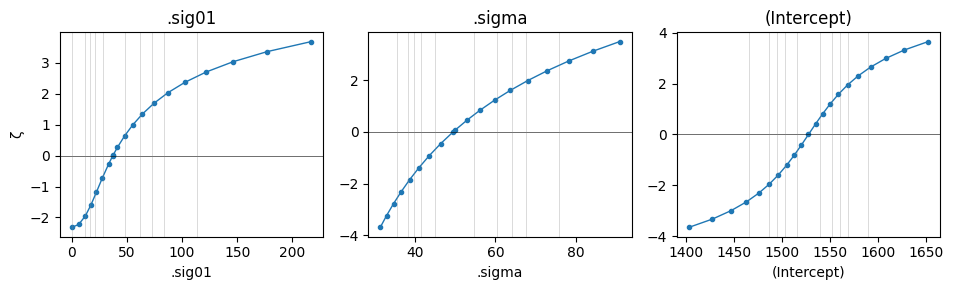

In [10]:
_ = pr01.plot()

Text(0, 0.5, 'ζ')

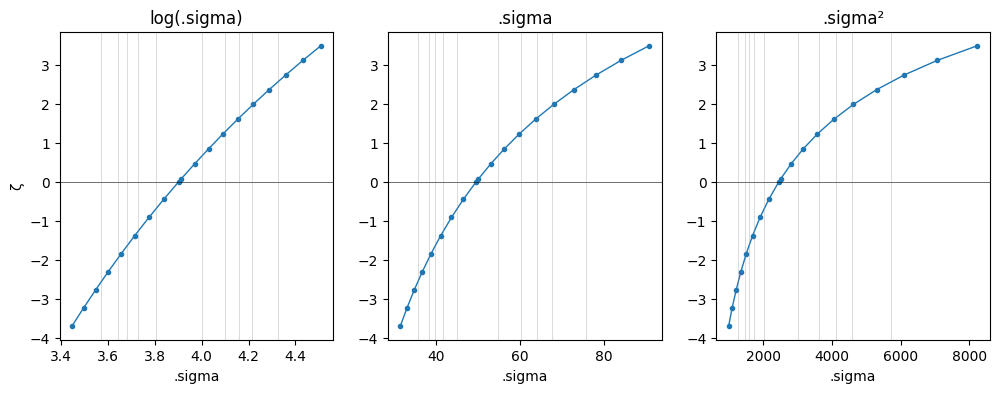

In [11]:
fig, ax = plt.subplot_mosaic("ABC", figsize=(12,4))
pr01.plot(which=".sigma", transform="log", ax=ax["A"])
pr01.plot(which=".sigma", ax=ax["B"])
pr01.plot(which=".sigma", transform="square", ax=ax["C"])
ax["A"].set_ylabel("ζ")

/Users/ziweih/Works/hea/hea/models/lme.py:6288: RuntimeWarning: divide by zero encountered in log
  x_at = fwd(np.asarray(v_at)).item()


Text(0, 0.5, 'ζ')

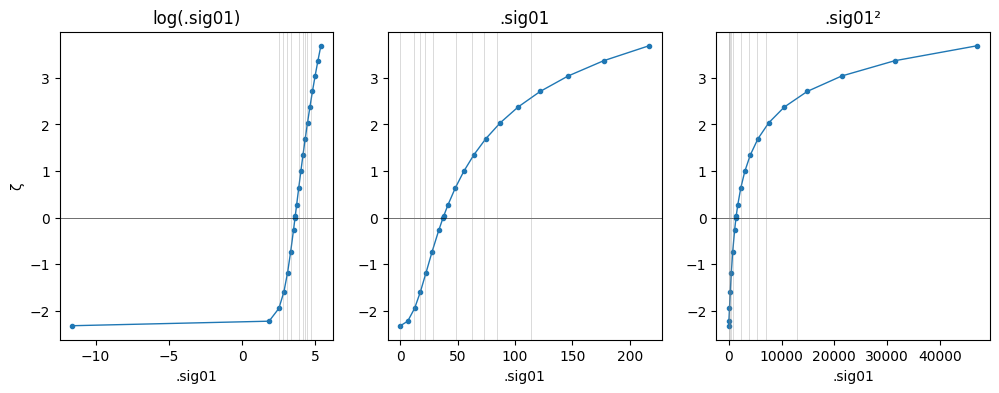

In [12]:
fig, ax = plt.subplot_mosaic("ABC", figsize=(12,4))
pr01.plot(which=".sig01", transform="log", ax=ax["A"])
pr01.plot(which=".sig01", ax=ax["B"])
pr01.plot(which=".sig01", transform="square", ax=ax["C"])
ax["A"].set_ylabel("ζ")

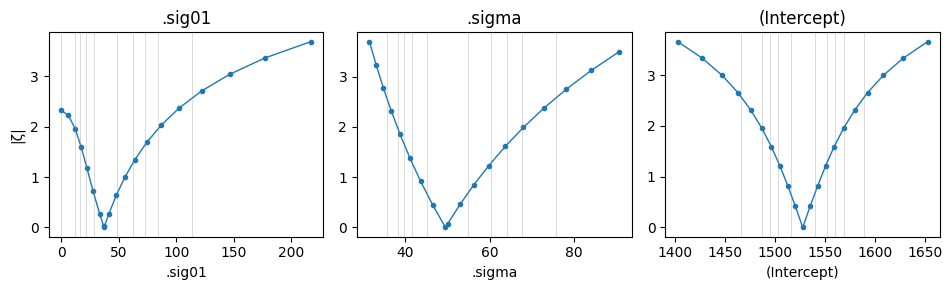

In [13]:
_ = pr01.plot(absolute=True)

In [14]:
pr01.confint(level=0.99)

parameter,0.5%,99.5%
str,f64,f64
""".sig01""",0.0,113.686279
""".sigma""",35.56321,75.667877
"""(Intercept)""",1465.87384,1589.126185


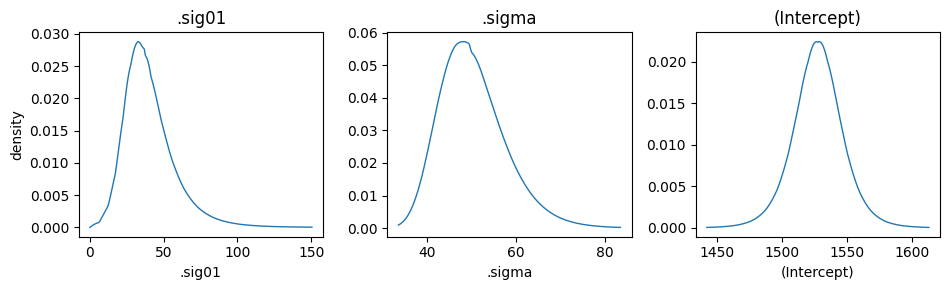

In [15]:
_ = pr01.plot_density()

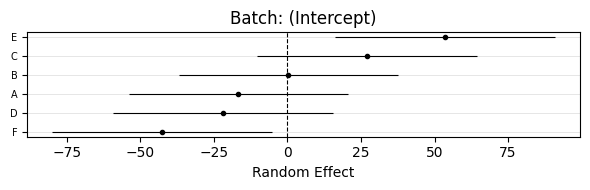

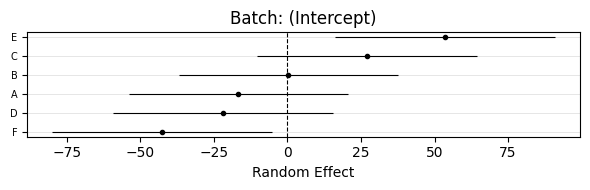

In [16]:
fm01ML.plot_ranef(figsize=(6, 2))

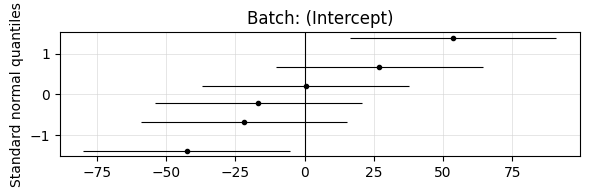

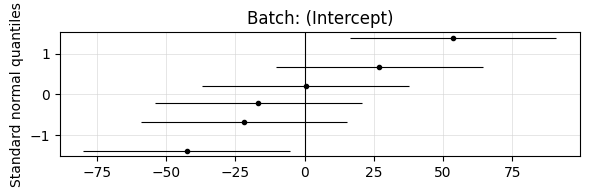

In [17]:
fm01ML.plot_qq_ranef(figsize=(6, 2))

### 2.1.1

In [18]:
penicillin = data("Penicillin", "lme4")
penicillin.describe()

statistic,diameter,plate,sample
str,f64,str,str
"""count""",144.0,"""144""","""144"""
"""null_count""",0.0,"""0""","""0"""
"""mean""",22.972222,null,null
"""std""",2.031034,null,null
"""min""",18.0,null,null
"""25%""",22.0,null,null
"""50%""",23.0,null,null
"""75%""",24.0,null,null
"""max""",27.0,null,null


In [19]:
penicillin["plate"].value_counts()

plate,count
enum,u32
"""m""",6
"""w""",6
"""p""",6
"""g""",6
"""e""",6
…,…
"""c""",6
"""j""",6
"""s""",6


In [20]:
penicillin["sample"].value_counts()

sample,count
enum,u32
"""F""",24
"""E""",24
"""A""",24
"""D""",24
"""C""",24
"""B""",24


In [21]:
fm03 = lme('diameter ~ 1 + (1 | plate) + (1 | sample)', penicillin)
fm03.summary()

Linear mixed model fit by REML
Formula: diameter ~ 1 + (1 | plate) + (1 | sample)

REML criterion at convergence: 330.8606

Scaled residuals:
    Min      1Q Median     3Q    Max
-2.0794 -0.6714 0.0629 0.5838 2.9798

Random effects:
 Groups   Name        Variance Std.Dev.
 plate    (Intercept) 0.7172   0.8468
 sample   (Intercept) 3.7359   1.9328
 Residual             0.3024   0.5499
Number of obs: 144, groups:  plate, 24; sample, 6

Fixed effects:
             Estimate  Std. Error  t value
(Intercept)   22.9722      0.8091    28.39


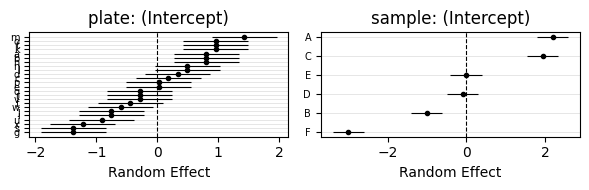

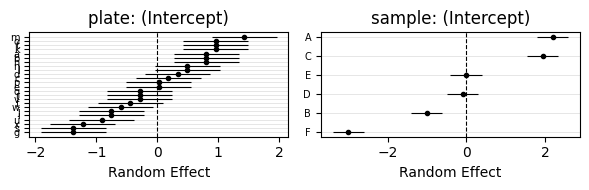

In [22]:
fm03.plot_ranef(figsize=(6, 2))

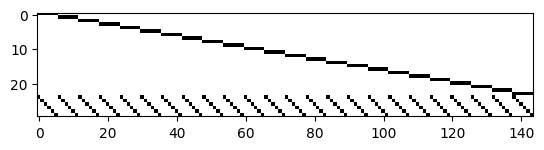

In [23]:
plt.imshow(fm03.Z.T, cmap="gray_r")

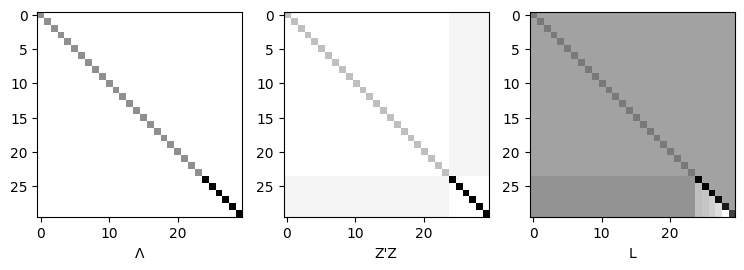

In [24]:
mosaic = [["Λ", "Z'Z", "L"]]
ZtZ = fm03.Z.T @ fm03.Z
fig, ax = plt.subplot_mosaic(mosaic=mosaic, figsize=(9, 3))
ax["Λ"].imshow(fm03.Lambda, cmap="gray_r")
ax["Z'Z"].imshow(ZtZ, cmap="gray_r")
ax["L"].imshow(fm03.L, cmap="gray_r")

for label, a in ax.items():
    a.set_xlabel(label)

In [25]:
pr03 = fm03.profile()

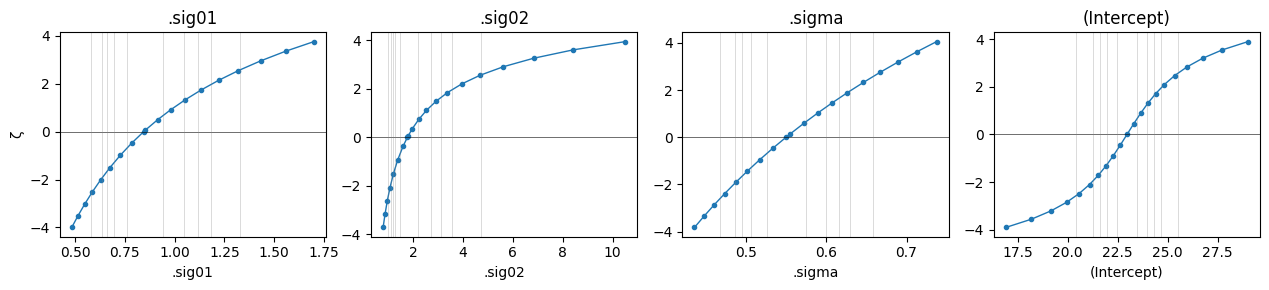

In [26]:
_ = pr03.plot()

In [27]:
pr03.confint()

parameter,2.5%,97.5%
str,f64,f64
""".sig01""",0.633566,1.182103
""".sig02""",1.095784,3.556271
""".sigma""",0.485845,0.629453
"""(Intercept)""",21.266593,24.677852


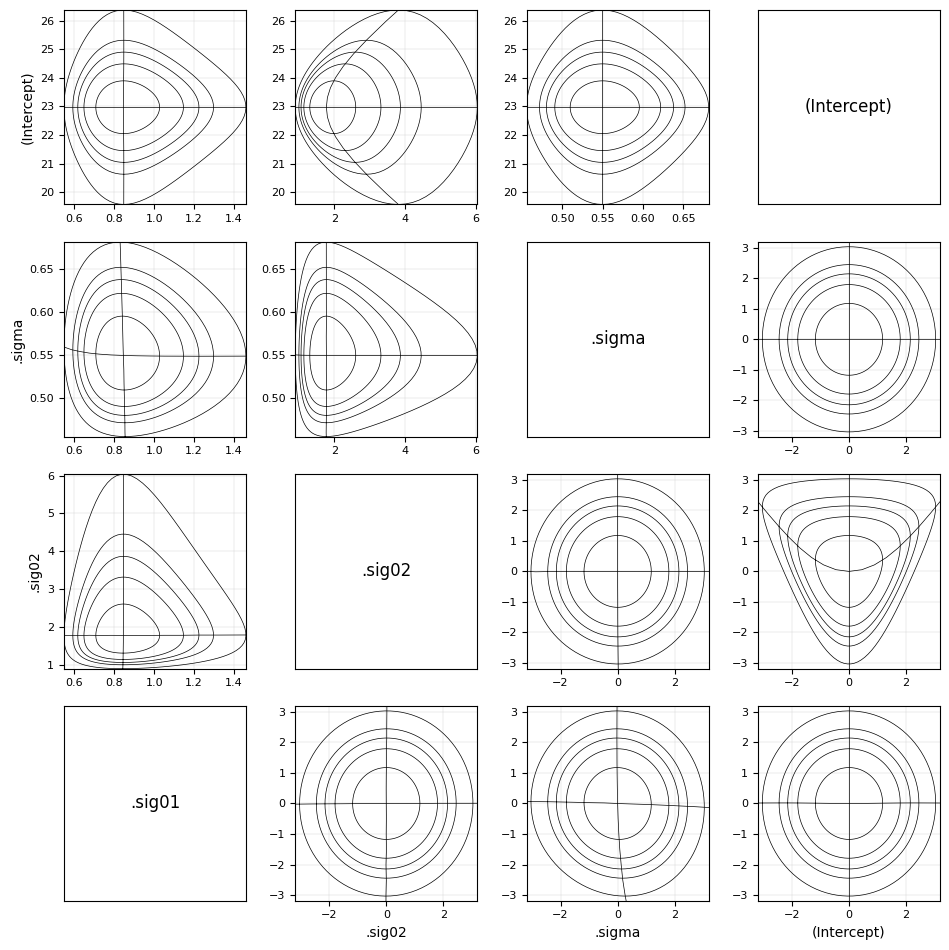

In [28]:
_ = pr03.plot_pairs()

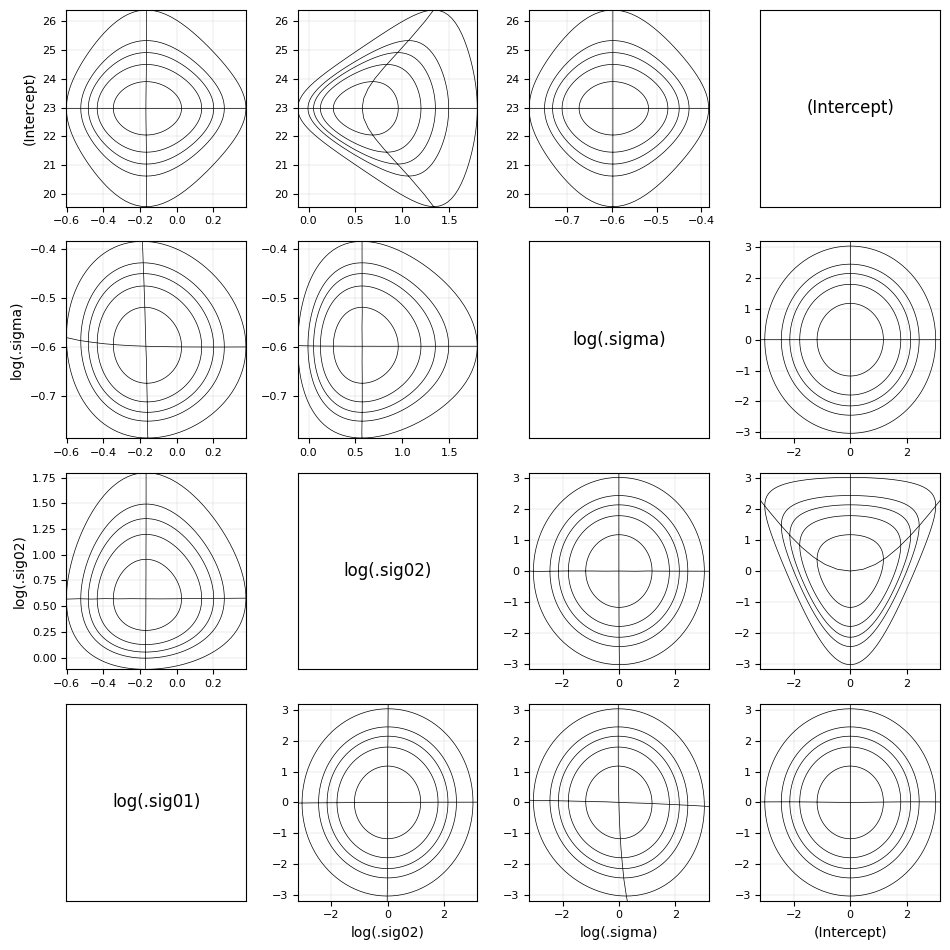

In [29]:
_ = pr03.plot_pairs(transform="log")

### 2.2.1

In [30]:
pastes = data("Pastes", "lme4")

In [31]:
fm04 = lme('strength ~ 1 + (1 | sample) + (1 | batch)', pastes, REML=False)

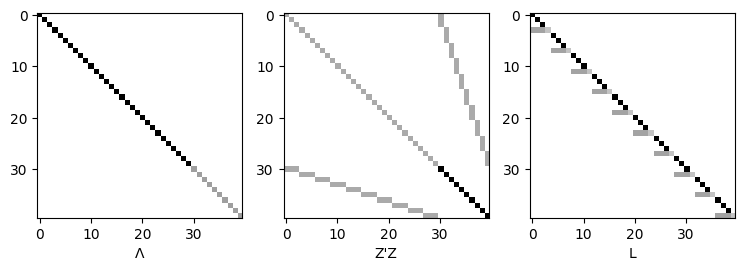

In [32]:
mosaic = [["Λ", "Z'Z", "L"]]
ZtZ = fm04.Z.T @ fm04.Z
fig, ax = plt.subplot_mosaic(mosaic=mosaic, figsize=(9, 3))
ax["Λ"].imshow(fm04.Lambda, cmap="gray_r")
ax["Z'Z"].imshow(ZtZ, cmap="gray_r")
ax["L"].imshow(fm04.L, cmap="gray_r")

for label, a in ax.items():
    a.set_xlabel(label)

In [33]:
fm04.summary()

Linear mixed model fit by maximum likelihood
Formula: strength ~ 1 + (1 | sample) + (1 | batch)

     AIC      BIC    logLik -2*log(L) df.resid
255.9945 264.3718 -123.9972  247.9945       56

Scaled residuals:
    Min      1Q Median     3Q    Max
-1.4847 -0.5263 0.0122 0.4674 1.3892

Random effects:
 Groups   Name        Variance Std.Dev.
 sample   (Intercept) 8.436    2.9045
 batch    (Intercept) 1.197    1.0939
 Residual             0.678    0.8234
Number of obs: 60, groups:  sample, 30; batch, 10

Fixed effects:
             Estimate  Std. Error  t value
(Intercept)   60.0533      0.6420    93.54


In [34]:
fm04a = lme('strength ~ 1 + (1 | sample)', pastes, REML=False)

In [35]:
fm04a.summary()

Linear mixed model fit by maximum likelihood
Formula: strength ~ 1 + (1 | sample)

     AIC      BIC    logLik -2*log(L) df.resid
254.4017 260.6847 -124.2009  248.4017       57

Scaled residuals:
    Min      1Q Median     3Q    Max
-1.4919 -0.5415 0.0150 0.4621 1.3884

Random effects:
 Groups   Name        Variance Std.Dev.
 sample   (Intercept) 9.6355   3.1041
 Residual             0.6778   0.8233
Number of obs: 60, groups:  sample, 30

Fixed effects:
             Estimate  Std. Error  t value
(Intercept)   60.0533      0.5766    104.1


In [36]:
anova(fm04a, fm04)

Analysis of Variance Table (likelihood ratio test)

fm04a: strength ~ 1 + (1 | sample)
fm04: strength ~ 1 + (1 | sample) + (1 | batch)

       npar       AIC       BIC     logLik  -2*log(L)   Chisq  Df  Pr(>Chisq)
fm04a     3  254.4017  260.6847  -124.2009   248.4017
fm04      4  255.9945  264.3718  -123.9972   247.9945  0.4072   1      0.5234
---
Signif. codes: 0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1


In [37]:
pr04 = fm04.profile()
pr04a = fm04a.profile()

In [38]:
pr04.confint(), pr04a.confint()

(shape: (4, 3)
 ┌─────────────┬───────────┬───────────┐
 │ parameter   ┆ 2.5%      ┆ 97.5%     │
 │ ---         ┆ ---       ┆ ---       │
 │ str         ┆ f64       ┆ f64       │
 ╞═════════════╪═══════════╪═══════════╡
 │ .sig01      ┆ 2.157932  ┆ 4.053583  │
 │ .sig02      ┆ 0.0       ┆ 2.946576  │
 │ .sigma      ┆ 0.652028  ┆ 1.085448  │
 │ (Intercept) ┆ 58.663633 ┆ 61.443034 │
 └─────────────┴───────────┴───────────┘,
 shape: (3, 3)
 ┌─────────────┬───────────┬───────────┐
 │ parameter   ┆ 2.5%      ┆ 97.5%     │
 │ ---         ┆ ---       ┆ ---       │
 │ str         ┆ f64       ┆ f64       │
 ╞═════════════╪═══════════╪═══════════╡
 │ .sig01      ┆ 2.430638  ┆ 4.122009  │
 │ .sigma      ┆ 0.65202   ┆ 1.085448  │
 │ (Intercept) ┆ 58.886182 ┆ 61.220485 │
 └─────────────┴───────────┴───────────┘)

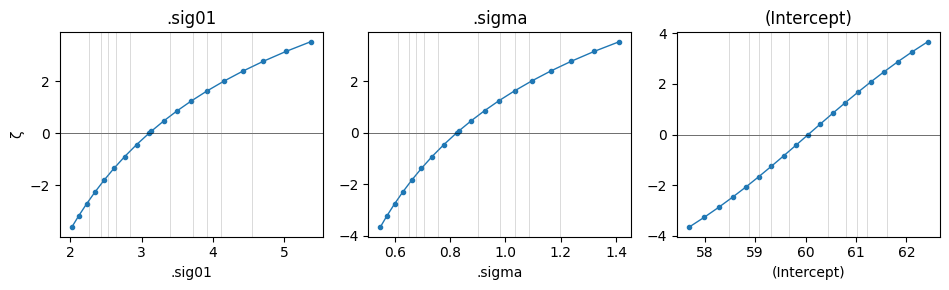

In [39]:
_ = pr04a.plot()

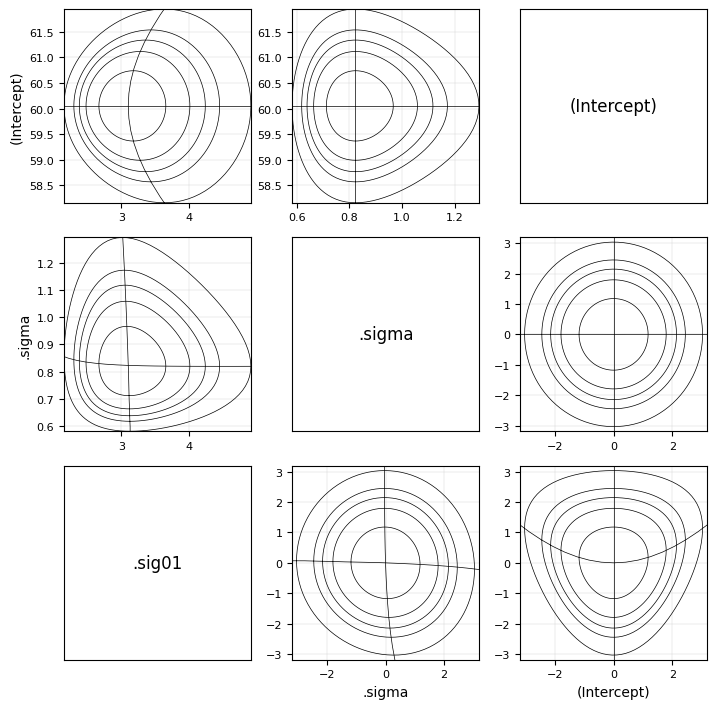

In [40]:
_ = pr04a.plot_pairs()

### 2.3.1

In [41]:
InstEval = data("InstEval", "lme4")

In [42]:
fm05 = lme('y ~ 1 + (1 | s) + (1 | d) + (1 | dept:service)', InstEval, REML=False)

In [43]:
fm05.summary()

Linear mixed model fit by maximum likelihood
Formula: y ~ 1 + (1 | s) + (1 | d) + (1 | dept:service)

        AIC         BIC       logLik   -2*log(L) df.resid
237663.2918 237709.3116 -118826.6459 237653.2918    73416

Scaled residuals:
    Min      1Q Median     3Q    Max
-2.9941 -0.7474 0.0400 0.7721 3.1124

Random effects:
 Groups       Name        Variance Std.Dev.
 s            (Intercept) 0.10541  0.3247
 d            (Intercept) 0.26256  0.5124
 dept:service (Intercept) 0.01213  0.1101
 Residual                 1.38495  1.1768
Number of obs: 73421, groups:  s, 2972; d, 1128; dept:service, 28

Fixed effects:
             Estimate  Std. Error  t value
(Intercept)   3.25521     0.02824    115.3


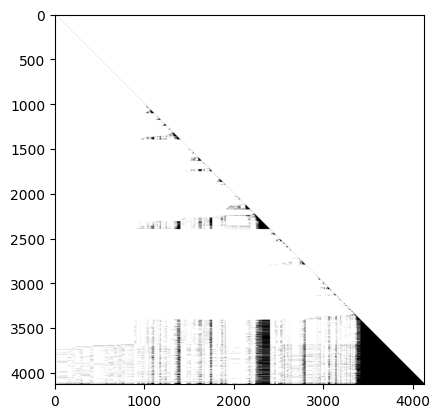

In [44]:
plt.imshow(fm05.L != 0, cmap="gray_r")

### 3.2.1

In [45]:
sleepstudy = data("sleepstudy", "lme4")

In [46]:
fm06 = lme('Reaction ~ 1 + Days + (1 + Days | Subject)', sleepstudy, REML=False)

In [47]:
fm06.summary()

Linear mixed model fit by maximum likelihood
Formula: Reaction ~ 1 + Days + (1 + Days | Subject)

      AIC       BIC    logLik -2*log(L) df.resid
1763.9393 1783.0971 -875.9697 1751.9393      174

Scaled residuals:
    Min      1Q Median     3Q    Max
-3.9416 -0.4656 0.0289 0.4636 5.1793

Random effects:
 Groups   Name        Variance Std.Dev. Corr
 Subject  (Intercept) 565.51   23.780
          Days        32.68    5.717    0.08
 Residual             654.94   25.592
Number of obs: 180, groups:  Subject, 18

Fixed effects:
             Estimate  Std. Error  t value
(Intercept)   251.405       6.632   37.906
Days           10.467       1.502    6.968

Correlation of Fixed Effects:
     (Intr)
Days -0.138


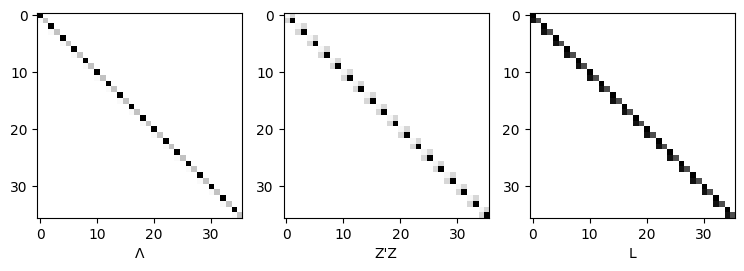

In [48]:
mosaic = [["Λ", "Z'Z", "L"]]
ZtZ = fm06.Z.T @ fm06.Z
fig, ax = plt.subplot_mosaic(mosaic=mosaic, figsize=(9, 3))
ax["Λ"].imshow(fm06.Lambda, cmap="gray_r")
ax["Z'Z"].imshow(ZtZ, cmap="gray_r")
ax["L"].imshow(fm06.L, cmap="gray_r")

for label, a in ax.items():
    a.set_xlabel(label)


### 3.2.2

In [49]:
fm07 = lme('Reaction ~ 1 + Days + (1 | Subject) + (0 + Days | Subject)', sleepstudy, REML=False)

In [50]:
fm07.summary()

Linear mixed model fit by maximum likelihood
Formula: Reaction ~ 1 + Days + (1 | Subject) + (0 + Days | Subject)

      AIC       BIC    logLik -2*log(L) df.resid
1762.0033 1777.9680 -876.0016 1752.0033      175

Scaled residuals:
    Min      1Q Median     3Q    Max
-3.9535 -0.4673 0.0239 0.4625 5.1883

Random effects:
 Groups    Name        Variance Std.Dev.
 Subject   (Intercept) 584.25   24.171
 Subject.1 Days        33.63    5.799
 Residual              653.12   25.556
Number of obs: 180, groups:  Subject, 18

Fixed effects:
             Estimate  Std. Error  t value
(Intercept)   251.405       6.708   37.480
Days           10.467       1.519    6.890

Correlation of Fixed Effects:
     (Intr)
Days -0.194


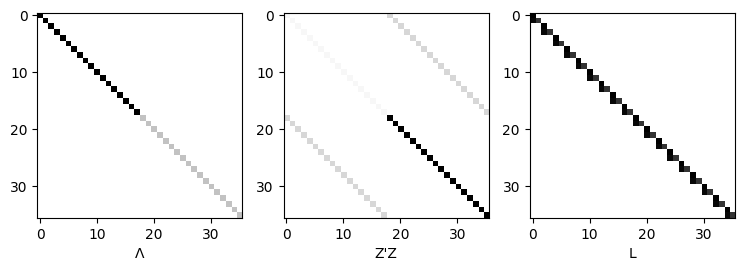

In [51]:
mosaic = [["Λ", "Z'Z", "L"]]
ZtZ = fm07.Z.T @ fm07.Z
fig, ax = plt.subplot_mosaic(mosaic=mosaic, figsize=(9, 3))
ax["Λ"].imshow(fm07.Lambda, cmap="gray_r")
ax["Z'Z"].imshow(ZtZ, cmap="gray_r")
ax["L"].imshow(fm07.L, cmap="gray_r")

for label, a in ax.items():
    a.set_xlabel(label)


Text(0.5, 1.0, "Z' of fm07")

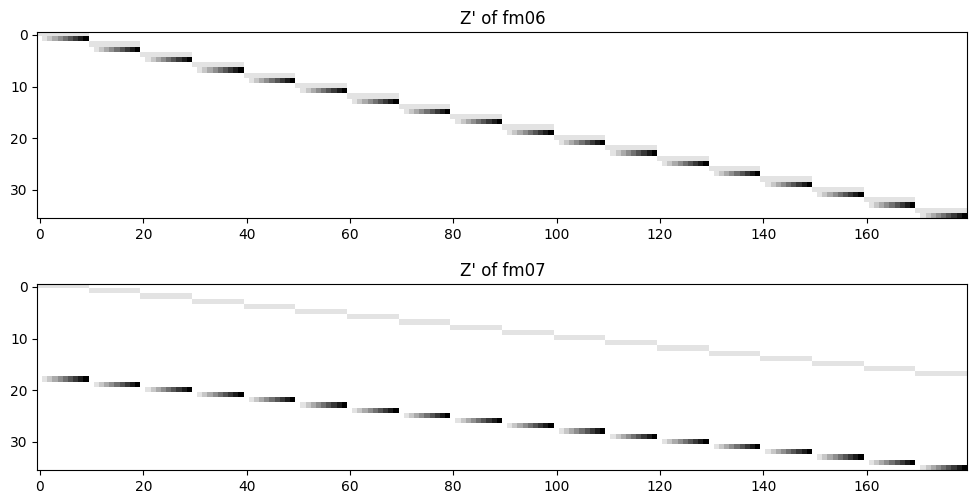

In [52]:
mosaic = """
A
B
"""
fig, ax = plt.subplot_mosaic(mosaic=mosaic, figsize=(12, 6))
ax["A"].imshow(fm06.Z.T, cmap="gray_r")
ax["B"].imshow(fm07.Z.T, cmap="gray_r")
ax["A"].set_title("Z' of fm06")
ax["B"].set_title("Z' of fm07")

### 3.2.4

In [53]:
anova(fm07, fm06)

Analysis of Variance Table (likelihood ratio test)

fm07: Reaction ~ 1 + Days + (1 | Subject) + (0 + Days | Subject)
fm06: Reaction ~ 1 + Days + (1 + Days | Subject)

      npar        AIC        BIC     logLik  -2*log(L)   Chisq  Df  Pr(>Chisq)
fm07     5  1762.0033  1777.9680  -876.0016  1752.0033
fm06     6  1763.9393  1783.0971  -875.9697  1751.9393  0.0639   1      0.8004
---
Signif. codes: 0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1


In [54]:
pr07 = fm07.profile()

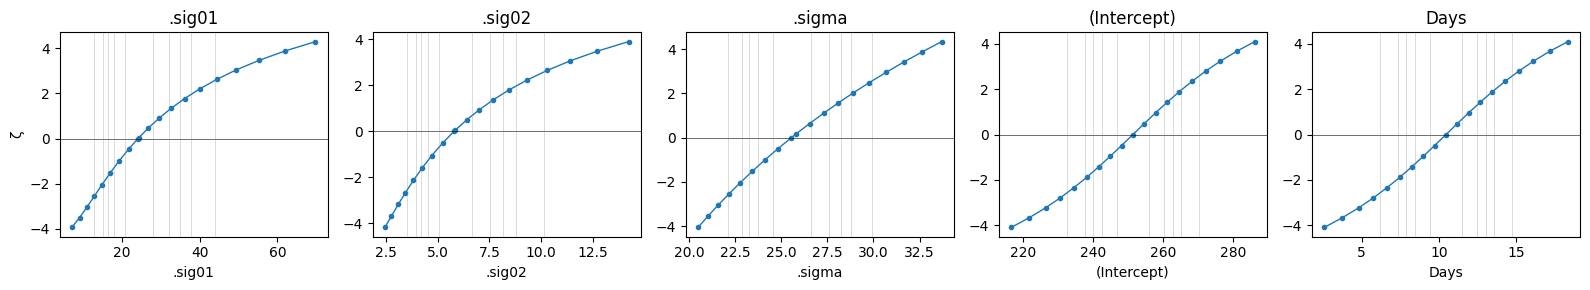

In [55]:
_ = pr07.plot()

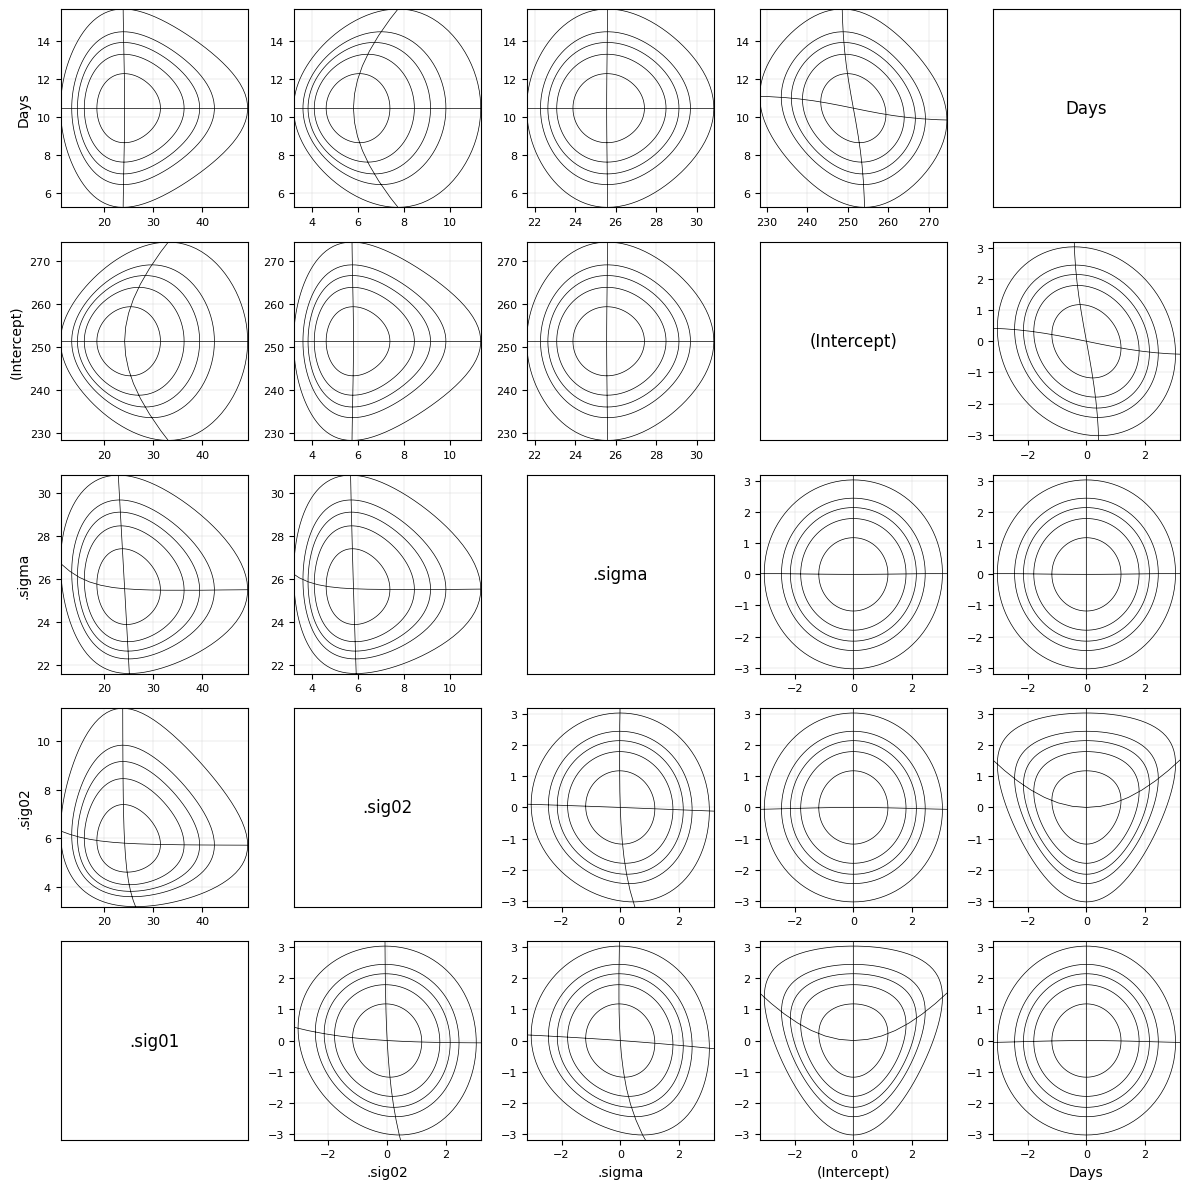

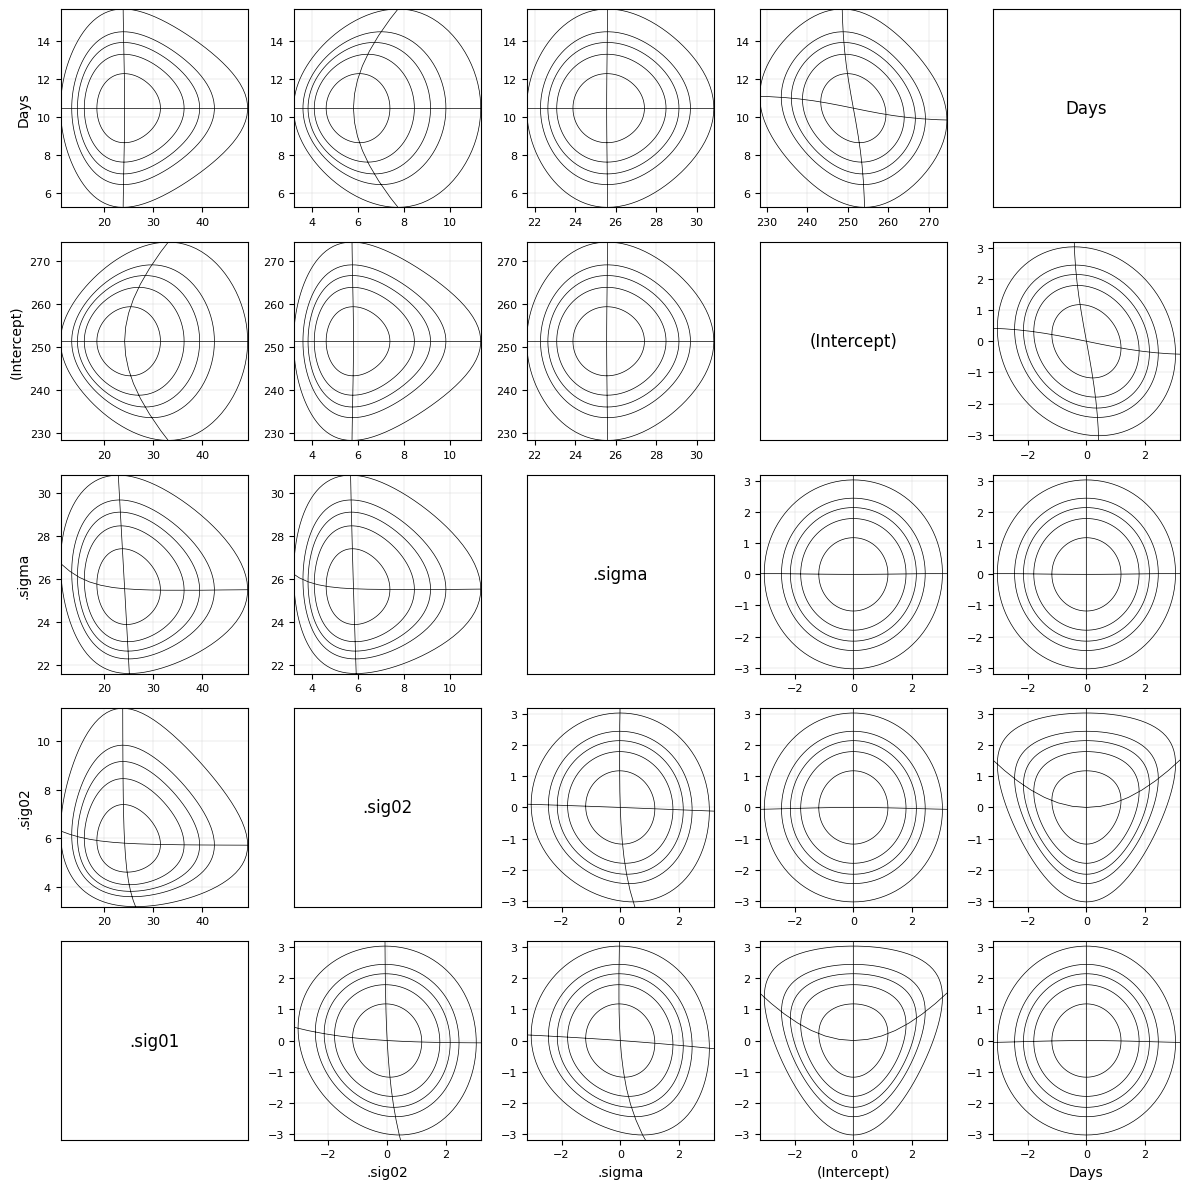

In [56]:
pr07.plot_pairs()

In [57]:
flm7 = lm('Reaction ~ Days * Subject', sleepstudy)

In [58]:
flm7.summary()

Formula: Reaction ~ Days * Subject

Residuals:
      Min       1Q  Median      3Q      Max
-106.3970 -10.6917 -0.1774 11.4174 132.5097

Coefficients:
                 Estimate  Std. Error  CI[2.5%]  CI[97.5]%  t value  Pr(>|t|)
(Intercept)       244.193      15.042  214.4616   273.9237  16.2344   < 2e-16  ***
Days               21.765       2.818   16.1956    27.3338   7.7246  1.74e-12  ***
Subject309        -39.138      21.272  -81.1837     2.9083  -1.8399  0.067848  .
Subject310        -40.708      21.272  -82.7545     1.3376  -1.9137  0.057643  .
Subject330         45.492      21.272    3.4464    87.5384   2.1386  0.034156  *
Subject331         41.546      21.272   -0.4997    83.5923   1.9531  0.052749  .
Subject332         20.059      21.272  -21.9871    62.1050   0.9430  0.347277
Subject333         30.826      21.272  -11.2196    72.8725   1.4491  0.149471
Subject334         -4.030      21.272  -46.0758    38.0163  -0.1894  0.850016
Subject335         18.842      21.272  -23.2040 

### 4.1

In [59]:
Machines = data("Machines", "nlme")

In [60]:
fm08 = lme('score ~ Machine + (1|Worker)', Machines, REML=False)
fm09 = lme('score ~ Machine + (Machine|Worker)', Machines, REML=False)
fm10 = lme('score ~ Machine + (1|Worker) + (1|Machine:Worker)', Machines, REML=False)

In [61]:
anova(fm08, fm09, fm10)

Analysis of Variance Table (likelihood ratio test)

fm08: score ~ Machine + (1|Worker)
fm09: score ~ Machine + (Machine|Worker)
fm10: score ~ Machine + (1|Worker) + (1|Machine:Worker)

      npar       AIC       BIC     logLik  -2*log(L)    Chisq  Df  Pr(>Chisq)
fm08     5  303.7033  313.6482  -146.8516   293.7033
fm10     6  237.2694  249.2034  -112.6347   225.2694  68.4338   1   1.312e-16  ***
fm09    10  236.4179  256.3077  -108.2089   216.4179   8.8516   4     0.06492  .
---
Signif. codes: 0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1


In [62]:
fm10.summary()

Linear mixed model fit by maximum likelihood
Formula: score ~ Machine + (1|Worker) + (1|Machine:Worker)

     AIC      BIC    logLik -2*log(L) df.resid
237.2694 249.2034 -112.6347  225.2694       48

Scaled residuals:
    Min      1Q  Median     3Q    Max
-2.2592 -0.5514 -0.0065 0.4467 2.5490

Random effects:
 Groups         Name        Variance Std.Dev.
 Machine:Worker (Intercept) 11.5456  3.3979
 Worker         (Intercept) 19.0423  4.3638
 Residual                   0.9245   0.9615
Number of obs: 54, groups:  Machine:Worker, 18; Worker, 6

Fixed effects:
             Estimate  Std. Error  t value
(Intercept)    52.356       2.269   23.072
MachineB        7.967       1.988    4.008
MachineC       13.917       1.988    7.001

Correlation of Fixed Effects:
           (Intr) MachineB
MachineB   -0.438
MachineC   -0.438    0.500


In [63]:
fm10.bhat

(Intercept),MachineB,MachineC
f64,f64,f64
52.355556,7.966667,13.916667


In [64]:
fm10._ranef()

[('Machine:Worker',
  ['A:6',
   'A:2',
   'A:4',
   'A:1',
   'A:3',
   'A:5',
   'B:6',
   'B:2',
   'B:4',
   'B:1',
   'B:3',
   'B:5',
   'C:6',
   'C:2',
   'C:4',
   'C:1',
   'C:3',
   'C:5'],
  ['(Intercept)'],
  array([[ 1.90678882],
         [ 1.54552219],
         [-1.0347905 ],
         [-0.74669192],
         [ 1.7704933 ],
         [-3.44132189],
         [-8.9371032 ],
         [ 0.60398666],
         [ 2.40668421],
         [ 1.49351332],
         [ 2.28996118],
         [ 2.14295783],
         [ 2.47495682],
         [-2.9835884 ],
         [-1.40815804],
         [-0.11359044],
         [-0.81061274],
         [ 2.8409928 ]]),
  array([[1.84512591],
         [1.84512591],
         [1.84512591],
         [1.84512591],
         [1.84512591],
         [1.84512591],
         [1.84512591],
         [1.84512591],
         [1.84512591],
         [1.84512591],
         [1.84512591],
         [1.84512591],
         [1.84512591],
         [1.84512591],
         [1.84512591],
 

In [65]:
from hea import session_info
session_info()

Python version 3.13.11 (CPython)
Platform: arm64-darwin25.4.0
Running under: macOS 26.4.1

BLAS:   accelerate
LAPACK: accelerate

locale: C.UTF-8

time zone: CEST

hea version 0.1.3

attached packages:
[1] IPython_9.13.0    hea_0.1.3         matplotlib_3.10.9 numpy_2.4.4
[5] pandas_3.0.2      polars_1.40.1     pyarrow_24.0.0    pytest_9.0.3
[9] scipy_1.17.1

loaded via a namespace (and not attached):
 [1] PIL_12.2.0              appnope_0.1.4           argparse_1.1
 [4] asttokens_3.0.1         comm_0.2.3              csv_1.0
 [7] ctypes_1.1.0            cycler_0.12.1           dateutil_2.9.0.post0
[10] debugpy_1.8.20          decimal_1.70            decorator_5.2.1
[13] defusedxml_0.7.1        executing_2.2.1         ipaddress_1.0
[16] ipykernel_7.2.0         jedi_0.19.2             json_2.0.9
[19] jupyter_client_8.8.0    jupyter_core_5.9.1      kiwisolver_1.5.0
[22] logging_0.5.1.2         matplotlib_inline_0.2.1 packaging_26.2
[25] parso_0.8.6             platform_1.0.8          plat